# Notebook 01 - Cleaning and Splitting the Guarani Wikipedia Dataset

## Goal of this notebook

The goal of this notebook is to prepare the Guarani Wikipedia dataset for the fine-tuning experiment.

In the previous notebook, I tested whether the dataset could be loaded successfully from Hugging Face. The dataset loaded correctly and sample rows showed usable Guarani text.

In this notebook, I will:

1. Load the Guarani Wikipedia dataset.
2. Inspect the raw data.
3. Keep only useful columns.
4. Remove empty, very short, and duplicate texts.
5. Limit the dataset to a small low-resource size.
6. Split the data into train, validation, and test sets.
7. Save the processed files for model training and evaluation.

Dataset source:

- Hugging Face dataset: https://huggingface.co/datasets/wikimedia/wikipedia
- Wikipedia source: https://gn.wikipedia.org

Important note:

This dataset is Paraguayan Guarani, not Guarani Mbya. Guarani Mbya is used as the real-world inspiration for the project, while this dataset is used to simulate the technical low-resource fine-tuning challenge.

In [19]:
# If these packages are not installed yet, run this cell once.
# After installation, restart the notebook kernel if needed.

import sys
!{sys.executable} -m pip install datasets pandas scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1 - Load the dataset

I load the `wikimedia/wikipedia` dataset with the Guarani subset `20231101.gn`.

This dataset contains Wikipedia articles in Paraguayan Guarani. I will use it as the training data candidate because it contains real text and has enough rows for a small low-resource experiment.


In [20]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.gn",
    split="train"
)

df = pd.DataFrame(dataset)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset shape: (5519, 4)
Columns: ['id', 'url', 'title', 'text']


,id,url,title,text
0,1,https://gn.wikipedia.org/wiki/Ayvu%20rapyta,Ayvu rapyta,Ayvu rapyta. León Cadogan omoĩ o kuatiañe'ẽme:...
1,7,https://gn.wikipedia.org/wiki/Ava%C3%B1e%27%E1...,Avañe'ẽ,Avañe'ẽ ombohéra hikuái umi Guaranikuéra-pe iñ...
2,842,https://gn.wikipedia.org/wiki/%C3%91orair%C3%B...,Ñorairõ Guasu Mokõiha,Ñorairõ Guasu Mokõiha ha'e akue peteĩ ñorairõ ...
3,843,https://gn.wikipedia.org/wiki/Don%20Quijote%20...,Don Quijote de la Mancha,Don Quijote de la Mancha ha'e peteĩ tembiasagu...
4,845,https://gn.wikipedia.org/wiki/Pete%C4%A9,Peteĩ,Peteĩ (1) ha'e papaha oúva mokõi mboyve mba'ev...


## Step 2 - Inspect the raw data

Before cleaning, I inspect the dataset structure.

The important columns are:

- `title`: the Wikipedia article title
- `text`: the article text

For fine-tuning, the `text` column is the most important because the model will learn from written Guarani text.

In [21]:
for i in range(5):
    print("Title:", df.loc[i, "title"])
    print("Text sample:", df.loc[i, "text"][:500])
    print("-" * 80)

Title: Ayvu rapyta
Text sample: Ayvu rapyta. León Cadogan omoĩ o kuatiañe'ẽme: Ayvu rapyta: Textos míticos de los Mbyá-Guarani del Guairá...

Mbya-Guarani Avano’õ Gueroviaré Ymaveguare Purahéi Jehaikue. Mbya-guarani Avano’õndy upépe oMombe’u mba’eichaitépe  (Hemimo’ãme) oÑepyrũ-va’ekue Ñe’e, Arapy tenondeve, Yporu Guasu (Diluvio Kastilla Ñe’ẽme), ha Mba’eichaitépa oñeMboÑepyrũ Opaite Mba’e. 
iPype jaJuhuta avei  Temimbo’e oPaichaguáva jaiKoPorahagua oÑondivepa, TekoPotime, ha oReko heta Morangu henyhetéva Arandu ha RoryRekógu
--------------------------------------------------------------------------------
Title: Avañe'ẽ
Text sample: Avañe'ẽ ombohéra hikuái umi Guaranikuéra-pe iñe'ẽ teépe. Guaranikuera ha'e peteĩva umi te'yikuéra Amérika-gua ñe'ẽnguéra apytépe hetave iñe'ẽhárava, oñemohendáva irundy tetãnguéra iñambuévape (Paraguái, Arahentína, Volívia ha Pindoráma). Avei, ha'eñoite ojehechakuaáva ñe'ẽ teéramo peteĩ tetã Ñembyamérika-guápe. 

Tupi ha guarani ñe'ẽ aty guasu rehegua, ogu

## Step 3 - Keep useful columns

The original dataset contains columns such as `id`, `url`, `title`, and `text`.

For this project, I only keep:

- `title`
- `text`

The `url` and `id` columns are useful for tracing the original source, but they are not needed for the first training dataset.

In [22]:
df_clean = df[["title", "text"]].copy()

print("Shape after selecting columns:", df_clean.shape)
df_clean.head()

Shape after selecting columns: (5519, 2)


,title,text
0,Ayvu rapyta,Ayvu rapyta. León Cadogan omoĩ o kuatiañe'ẽme:...
1,Avañe'ẽ,Avañe'ẽ ombohéra hikuái umi Guaranikuéra-pe iñ...
2,Ñorairõ Guasu Mokõiha,Ñorairõ Guasu Mokõiha ha'e akue peteĩ ñorairõ ...
3,Don Quijote de la Mancha,Don Quijote de la Mancha ha'e peteĩ tembiasagu...
4,Peteĩ,Peteĩ (1) ha'e papaha oúva mokõi mboyve mba'ev...


## Step 4 - Basic cleaning

In this step, I remove examples that are not useful for training.

I remove:

- missing values
- empty texts
- very short texts
- duplicate texts

Very short texts are removed because they do not give the model enough language context to learn from.

In [23]:
before_rows = len(df_clean)

# Remove missing values
df_clean = df_clean.dropna(subset=["title", "text"])

# Remove empty or whitespace-only texts
df_clean = df_clean[df_clean["text"].str.strip() != ""]

# Remove very short texts
df_clean = df_clean[df_clean["text"].str.len() > 200]

# Remove duplicate texts
df_clean = df_clean.drop_duplicates(subset=["text"])

after_rows = len(df_clean)

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", before_rows - after_rows)

df_clean.head()

Rows before cleaning: 5519
Rows after cleaning: 3535
Rows removed: 1984


,title,text
0,Ayvu rapyta,Ayvu rapyta. León Cadogan omoĩ o kuatiañe'ẽme:...
1,Avañe'ẽ,Avañe'ẽ ombohéra hikuái umi Guaranikuéra-pe iñ...
2,Ñorairõ Guasu Mokõiha,Ñorairõ Guasu Mokõiha ha'e akue peteĩ ñorairõ ...
3,Don Quijote de la Mancha,Don Quijote de la Mancha ha'e peteĩ tembiasagu...
5,Umi Ñemongu'e Joguerahaviárava Remimbopokuérav...,Umi Ñemongu’e Joguerahaviárava Remimbopokuérav...


## Cleaning observation

After cleaning, the dataset changed from 5,519 rows to 3,535 rows. This means 1,984 rows were removed.

At first, this looked like a large amount of data loss to me. In my previous machine learning experience, I usually worked with structured datasets, where losing this many rows would be concerning.

However, this project uses text data. In text fine-tuning, quality is more important than simply keeping every row. Many Wikipedia rows can be very short articles, stubs, number pages, or incomplete texts. These rows may not provide enough language context for the model to learn useful writing patterns.

The biggest reason for the row reduction is probably the minimum text length filter:

`text length > 200`

This removes very short texts. For this project, that is acceptable because the goal is to fine-tune on useful Guarani text, not to keep every article.

## Cleaning visualization

I visualize the cleaning result to understand how much data was removed.

This is useful because the dataset lost many rows after cleaning. As a former ML student, I found this interesting because I usually did not lose this much data during cleaning. In this case, it makes sense because Wikipedia contains many very short articles and stubs.

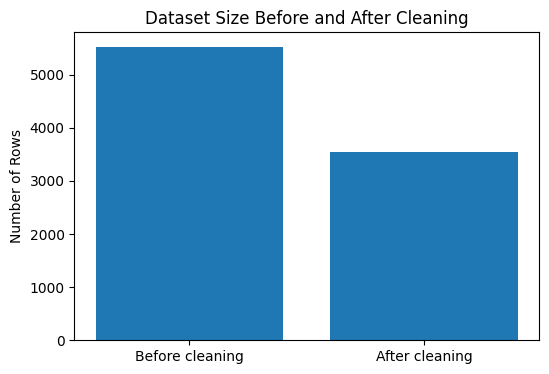

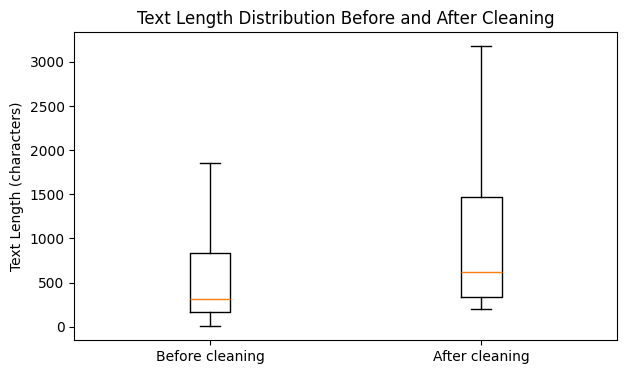

In [24]:
import matplotlib.pyplot as plt

row_counts = {
    "Before cleaning": before_rows,
    "After cleaning": after_rows
}

plt.figure(figsize=(6, 4))
plt.bar(row_counts.keys(), row_counts.values())
plt.title("Dataset Size Before and After Cleaning")
plt.ylabel("Number of Rows")
plt.show()

df_before_plot = df[["title", "text"]].copy()
df_before_plot = df_before_plot.dropna(subset=["text"])
df_before_plot["text_length"] = df_before_plot["text"].str.len()

df_after_plot = df_clean.copy()
df_after_plot["text_length"] = df_after_plot["text"].str.len()

plt.figure(figsize=(7, 4))
plt.boxplot(
    [df_before_plot["text_length"], df_after_plot["text_length"]],
    tick_labels=["Before cleaning", "After cleaning"],
    showfliers=False
)
plt.title("Text Length Distribution Before and After Cleaning")
plt.ylabel("Text Length (characters)")
plt.show()

## Step 5 - Limit the dataset size

After cleaning, 3,535 usable rows remained.

I decided to use 3,000 examples instead of 2,000 because the dataset is still small enough for a low-resource experiment, but 3,000 examples give the model more language patterns to learn from.

I do not use the full 3,535 rows in the first version because I want to keep the experiment controlled and realistic for the available time and hardware.

In [25]:
target_size = 3000

if len(df_clean) >= target_size:
    df_small = df_clean.sample(n=target_size, random_state=42)
else:
    df_small = df_clean.copy()

print("Selected dataset size:", len(df_small))
df_small.head()

Selected dataset size: 3000


,title,text
661,Kuarahy,Kuarahy (mba'ehero: ) ha'e peteĩ mbyja ojejuhú...
3481,Montenégyro,Montenégyro (Montenégyro ñe'ẽme: Crna Gora) ha...
3796,Georges Lemaître,Georges Henri Joseph Édouard Lemaître (/ləˈmɛt...
3071,Y (tai),"Tai Y ha'e tai mokõipa poha, pundie térã pu'ae..."
570,Tague,Tague () mba'e raviju térã mba'e akua osẽva má...


## Step 6 - Split into train, validation, and test sets

The dataset is split into three parts:

- Train set: used to fine-tune the model
- Validation set: used to check the model during training
- Test set: used only at the end for evaluation

The test set must stay unseen by the model. This helps me evaluate whether the model generalizes or only memorizes training examples.

I use an 80/10/10 split:

- 80% train
- 10% validation
- 10% test

In [26]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_small,
    test_size=0.2,
    random_state=42
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(validation_df))
print("Test size:", len(test_df))

Train size: 2400
Validation size: 300
Test size: 300


## Train, validation, and test visualization

I visualize the split to confirm that the dataset was divided correctly.

The train set is the largest part because the model learns from it. The validation and test sets are smaller because they are used for checking and final evaluation.

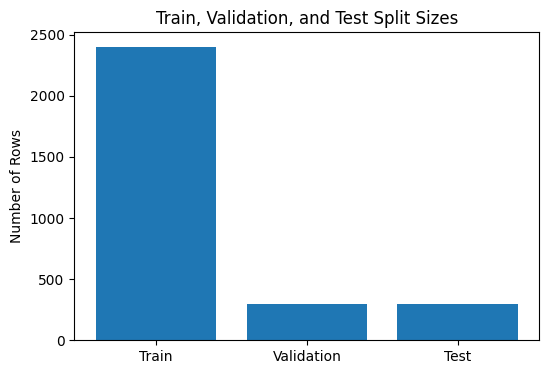

In [27]:
split_counts = {
    "Train": len(train_df),
    "Validation": len(validation_df),
    "Test": len(test_df)
}

plt.figure(figsize=(6, 4))
plt.bar(split_counts.keys(), split_counts.values())
plt.title("Train, Validation, and Test Split Sizes")
plt.ylabel("Number of Rows")
plt.show()

## Step 7 - Save the processed files

The cleaned and split datasets are saved as CSV files.

These files will be used in later notebooks:

- `train.csv` for fine-tuning
- `validation.csv` for checking during training
- `test.csv` for final evaluation

In [28]:
from pathlib import Path

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

train_df.to_csv(processed_path / "train.csv", index=False)
validation_df.to_csv(processed_path / "validation.csv", index=False)
test_df.to_csv(processed_path / "test.csv", index=False)

print("Files saved:")
print(processed_path / "train.csv")
print(processed_path / "validation.csv")
print(processed_path / "test.csv")

Files saved:
..\data\processed\train.csv
..\data\processed\validation.csv
..\data\processed\test.csv


## Step 8 - Final check

I check whether the saved files can be loaded again correctly.

This confirms that the processed dataset is ready for the next step: baseline model testing and fine-tuning.

In [29]:
train_check = pd.read_csv(processed_path / "train.csv")
validation_check = pd.read_csv(processed_path / "validation.csv")
test_check = pd.read_csv(processed_path / "test.csv")

print("Train:", train_check.shape)
print("Validation:", validation_check.shape)
print("Test:", test_check.shape)

train_check.head()

Train: (2400, 2)
Validation: (300, 2)
Test: (300, 2)


,title,text
0,Soroátoro jerovia,Soroátoro jerovia térã zoroastrismo ha'e peteĩ...
1,Ysyrykuéra rysýi pukukuére,Ko tysýipe oĩ opaite ysyry pukúva. Umíva 1000 ...
2,Kãchẽjunga,"Kãchẽjunga térã Kanchenjunga, ha'e niko peteĩ ..."
3,Kuala Lumpur,Kuala Lumpur (Malájo ñe'ẽme: Kuala Lumpur térã...
4,Laços de Família,"Laços de Família, ha'e akue peteĩ tembiasagua'..."


## Conclusion

The Guarani Wikipedia dataset was loaded, inspected, cleaned, limited to a low-resource size, and split into train, validation, and test sets.

The final processed files are:

- `data/processed/train.csv`
- `data/processed/validation.csv`
- `data/processed/test.csv`

This dataset is now ready for the next project step: baseline model testing.

Important limitation:

This dataset is Paraguayan Guarani, not Guarani Mbya. I will not claim that the model represents Guarani Mbya directly. The purpose is to test the technical fine-tuning workflow in a low-resource language setting.